###Ejercicio 1):
 Utilice lo aprendido en los trabajos prácticos previos (uso de biopython para obtenersecuencias, BLAST y el “parser del mismo”) para:

 i) obtener 10 secuencias pertenecientes a una misma familia y

 ii) Alinearlas y obtener la correspondiente matriz de puntaje / identidad

 Analice si la matriz es (o no) simetrica

 Compare matrices utilizando diferentes puntajes que le otorga BLAST (Bit Score, Identidad, E-Value)

Lista de 10 proteinas CYP1A1 de distintas especies

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.3 MB/s eta 0:00:00


In [23]:
from Bio import SeqIO, pairwise2
from Bio.Align import substitution_matrices
import numpy as np
import pandas as pd
import copy
from Bio import Phylo
from io import StringIO


In [3]:
!wget ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/ncbi-blast-*-x64-linux.tar.gz
!tar -xzf ncbi-blast-*-x64-linux.tar.gz
!mv ncbi-blast-*/bin/* /usr/local/bin/


--2025-09-26 12:39:26--  ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/ncbi-blast-*-x64-linux.tar.gz
           => ‘.listing’
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 130.14.250.13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /blast/executables/blast+/LATEST ... done.
==> PASV ... done.    ==> LIST ... done.

.listing                [ <=>                ]   2.62K  --.-KB/s    in 0.02s   

2025-09-26 12:39:27 (174 KB/s) - ‘.listing’ saved [2678]

Removed ‘.listing’.
--2025-09-26 12:39:27--  ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast%2B/LATEST/ncbi-blast-2.17.0%2B-x64-linux.tar.gz
           => ‘ncbi-blast-2.17.0+-x64-linux.tar.gz’
==> CWD not required.
==> PASV ... done.    ==> RETR ncbi-blast-2.17.0+-x64-linux.tar.gz ... done.
Length: 296006458 (282M)

ncbi-bl

In [5]:
import pandas as pd
def cargar_blosum60(path="blosum60.txt"):
    with open(path) as f:
        lines = [line.strip() for line in f if not line.startswith("#")]

    header = lines[0].split()
    data = []
    index = []

    for line in lines[1:]:
        parts = line.split()
        index.append(parts[0])
        data.append([int(x) for x in parts[1:]])

    df = pd.DataFrame(data, index=index, columns=header)
    return df

# Cargar matriz
blosum60_df = cargar_blosum60()

# Mostrar parte de la matriz

def df_to_blosum_dict(df):
    matrix = {}
    for i in df.index:
        for j in df.columns:
            score = df.at[i, j]
            matrix[(i, j)] = score
            matrix[(j, i)] = score  # aseguramos simetría
    return matrix


blosum_dict = df_to_blosum_dict(blosum60_df)
print(blosum_dict)


{('A', 'A'): np.int64(5), ('A', 'R'): np.int64(-2), ('R', 'A'): np.int64(-2), ('A', 'N'): np.int64(-1), ('N', 'A'): np.int64(-1), ('A', 'D'): np.int64(-2), ('D', 'A'): np.int64(-2), ('A', 'C'): np.int64(-1), ('C', 'A'): np.int64(-1), ('A', 'Q'): np.int64(-1), ('Q', 'A'): np.int64(-1), ('A', 'E'): np.int64(-1), ('E', 'A'): np.int64(-1), ('A', 'G'): np.int64(0), ('G', 'A'): np.int64(0), ('A', 'H'): np.int64(-2), ('H', 'A'): np.int64(-2), ('A', 'I'): np.int64(-2), ('I', 'A'): np.int64(-2), ('A', 'L'): np.int64(-2), ('L', 'A'): np.int64(-2), ('A', 'K'): np.int64(-1), ('K', 'A'): np.int64(-1), ('A', 'M'): np.int64(-1), ('M', 'A'): np.int64(-1), ('A', 'F'): np.int64(-3), ('F', 'A'): np.int64(-3), ('A', 'P'): np.int64(-1), ('P', 'A'): np.int64(-1), ('A', 'S'): np.int64(1), ('S', 'A'): np.int64(1), ('A', 'T'): np.int64(0), ('T', 'A'): np.int64(0), ('A', 'W'): np.int64(-4), ('W', 'A'): np.int64(-4), ('A', 'Y'): np.int64(-2), ('Y', 'A'): np.int64(-2), ('A', 'V'): np.int64(0), ('V', 'A'): np.int6

**def blast_two_seqs**

    """
    Hace BLASTp local entre dos secuencias proteicas y devuelve métricas clave.

    Args:
      seq_query (str): Secuencia proteica que será la consulta.
      seq_db (str): Secuencia proteica que será la base de datos.
      id_query (str): ID para la secuencia consulta.
      id_db (str): ID para la secuencia base de datos.
      temp_dir (str): Carpeta temporal para archivos.

    Returns:
      tuple: (evalue, bitscore, pident) del mejor hit.
             Si no hay hits, devuelve (None, None, None).
    """

In [6]:
import os

def blast_two_seqs(seq_query, seq_db, id_query="query", id_db="db", temp_dir="temp_blast"):
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)

    # Crear archivo fasta para consulta
    query_path = os.path.join(temp_dir, "query.fasta")
    with open(query_path, "w") as f:
        f.write(f">{id_query}\n{seq_query}\n")

    # Crear archivo fasta para base de datos
    db_path = os.path.join(temp_dir, "db.fasta")
    with open(db_path, "w") as f:
        f.write(f">{id_db}\n{seq_db}\n")

    # Crear base de datos local
    db_name = os.path.join(temp_dir, "db")
    cmd_make_db = f"makeblastdb -in {db_path} -dbtype prot -out {db_name} -logfile /dev/null"
    os.system(cmd_make_db)

    # Ejecutar blastp
    output_path = os.path.join(temp_dir, "blast_out.txt")
    cmd_blast = (
        f"blastp -query {query_path} -db {db_name} "
        f"-out {output_path} -outfmt '6 evalue bitscore pident' "
        f"-max_target_seqs 1 -num_threads 1"
    )
    os.system(cmd_blast)

    # Leer resultado
    evalue, bitscore, pident = None, None, None
    if os.path.exists(output_path):
        with open(output_path) as f:
            line = f.readline().strip()
            if line:
                evalue_str, bitscore_str, pident_str = line.split("\t")
                evalue = float(evalue_str)
                bitscore = float(bitscore_str)
                pident = float(pident_str)

    return evalue, bitscore, pident


#Obtenemos 10 secuencias de la familia quinasa

In [7]:

from Bio import Entrez, SeqIO

Entrez.email = "joaquinsalva03@gmail.com"

# Paso 1: buscar proteínas asociadas a una familia en NCBI Protein
# Ejemplo: globinas
handle = Entrez.esearch(
    db="protein",
    term="Protein kinase[Protein Name]",
    retmax=10  # cantidad de secuencias a traer
)
record = Entrez.read(handle)
handle.close()

print("IDs encontrados:", record["IdList"])

# Paso 2: bajar las secuencias en formato fasta
handle = Entrez.efetch(
    db="protein",
    id=",".join(record["IdList"]),
    rettype="fasta",
    retmode="text"
)

# Paso 3: parsear a strings y guardarlas en una lista
lista_quinasas = [str(rec.seq) for rec in SeqIO.parse(handle, "fasta")]
handle.close()

print("Número de secuencias:", len(lista_quinasas))



IDs encontrados: ['3064162935', '3064158066', '3063888818', '3063884927', '3063834559', '3063804125', '2924247891', '2575255726', '2573173597', '2511548032']
Número de secuencias: 10


In [8]:
def guardar_lista_fasta(lista_secuencias, output_path="secuencias.fasta", prefix="Prot_"):
    with open(output_path, "w") as f:
        for i, seq in enumerate(lista_secuencias):
            f.write(f">{prefix}{i}\n")
            f.write(f"{seq}\n")
guardar_lista_fasta(lista_quinasas, "quinasas.fasta")


In [9]:
# Cargar matriz
blosum60_df = cargar_blosum60()
def obtener_matriz_blast_scores(lista_proteinas):
    # Inicializar matriz
    n = len(lista_proteinas)
    evalue_matrix, bitscore_matrix, pident_matrix = np.zeros((n, n)), np.zeros((n, n)),np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            seq1 = lista_proteinas[i]
            seq2 = lista_proteinas[j]
            evalue, bitscore, pident = blast_two_seqs(seq1, seq2)
            evalue_matrix[i][j]= evalue
            bitscore_matrix[i][j] = bitscore
            pident_matrix[i][j]  =  pident


    maximo = np.nanmax(evalue_matrix)
    evalue_matrix = np.nan_to_num(evalue_matrix, nan=maximo)

    bitscore_matrix = np.nan_to_num(bitscore_matrix, nan=0)

    pident_matrix = np.nan_to_num(pident_matrix, nan=0)
    return evalue_matrix, bitscore_matrix, pident_matrix

Ejercicio 2): Programe un algoritmo que dada una matriz de distancias construya un árbol guía.Utilice el mismo para trabajar con las diferentes matrices obtenidas a partir de los puntajes deBLAST y analice los resultados de manera comparativa.

# De la matriz al arbol guia

## De la matriz al arbol

Tomamos la matriz de distancias y, reduciendo su dimension, calculamos el agrupamiento de nodos del arbol guia

Para esto tenemos que:

* Tener una matriz de distancias donde las columnas y las filas son un conjunto de secuencias (que lo llamamos C).
* encontrar el maximo valor de la matriz
  junto con sus coordenadas
  maximo = distancia (A,B), con A,B en C, y su distancia el maximo score, es decir, mayor parecido entre si.  
* Quito las filas y columnas donde se vea distancias de A o B a otra secuencia X
* Armo una fila que sea distancia ((AB, X)

De esta manera, evitamos recalcular toda la matriz de distancia, donde lo que nos interesa modificar es aquellas filas, columnas que se vean afectadas

## Graficar el arbol guia

Encontrar minimo y maximo nos permiten personalizar la matriz que hace el arbol guia segun si queremos hacerlo por e-value o pident.

Actualizar matriz reduce la dimension de la matriz, actualizadola al alineamiento multiple que se tomo de acuerdo al minimo o maximo.


In [10]:
import numpy as np

def imprimir_matriz(matriz, etiquetas):
    print("\nMatriz actual:")
    df = pd.DataFrame(matriz, index=etiquetas, columns=etiquetas)
    display(df)
    return

def encontrar_maximo(matriz):
    n = len(matriz)
    max_val = float('-inf')  # empezamos desde -infinito
    coords = (-1, -1)
    for i in range(n):
        for j in range(i+1, n):  # triángulo superior
            if matriz[i][j] > max_val:
                max_val = matriz[i][j]
                coords = (i, j)
    return coords, max_val

def encontrar_minimo(matriz):
    n = len(matriz)
    min_val = float('inf')  # empezamos desde infinito
    coords = (-1, -1)
    for i in range(n):
        for j in range(i+1, n):  # triángulo superior
            if matriz[i][j] < min_val:
                min_val = matriz[i][j]
                coords = (i, j)
    return coords, min_val


def calcular_distancia_promedio(matriz, i, j):
    n = len(matriz)
    nueva_fila = []
    for k in range(n):
        if k != i and k != j:
            d = (matriz[i][k] + matriz[j][k]) / 2
            nueva_fila.append(d)
    return nueva_fila

def actualizar_matriz(matriz, etiquetas, i, j):
    # Unimos etiquetas como una string (sin espacios si lo querés tipo Newick)
    nueva_etiqueta = f"({etiquetas[i]},{etiquetas[j]})"

    nueva_fila = calcular_distancia_promedio(matriz, i, j)

    # Eliminar i y j (mayor índice primero)
    indices = sorted([i, j], reverse=True)
    for idx in indices:
        matriz = np.delete(matriz, idx, axis=0)
        matriz = np.delete(matriz, idx, axis=1)
        etiquetas.pop(idx)

    # Agregar nueva fila/columna
    matriz = np.vstack([matriz, nueva_fila])
    nueva_col = nueva_fila + [0.0]
    matriz = np.column_stack([matriz, nueva_col])
    etiquetas.append(nueva_etiqueta)

    return matriz, etiquetas


   ### armar_arbol_guia

    """
    Genera arbol en formato newick

    Args:
        matriz: matriz de puntajes de alineamientos todas con todas.
        etiquetas: Forma de identificar a cada secuencia que aparecera en el arbol
        tipo_score: Cual fue el criterio de agrupamiento (minimo e-value, maximo pident)
    """

In [11]:
def armar_arbol_guia(matriz, etiquetas, tipo_score):
      paso = 1
      while len(etiquetas) > 1:
          imprimir_matriz(matriz, etiquetas)
          if tipo_score in ['bitscore', 'pident']:
              (i, j), max_val = encontrar_maximo(matriz)
              print(f"\nPaso {paso}: Agrupando '{etiquetas[i]}' y '{etiquetas[j]}' con {tipo_score} maximo {max_val}")

          if tipo_score == 'evalue':
              (i, j), min_val = encontrar_minimo(matriz)
              print(f"\nPaso {paso}: Agrupando '{etiquetas[i]}' y '{etiquetas[j]}' con evalue mínimo {min_val}")

          matriz, etiquetas = actualizar_matriz(matriz, etiquetas, i, j)
          paso += 1

      print("\nÁrbol final:", etiquetas[0])
      return etiquetas[0]


Miramos los distintos arboles guias que se generan de acuerdo a si los armamos por bitscore, pident o e-value

In [13]:

evalue_matrix, bitscore_matrix, pident_matrix = obtener_matriz_blast_scores(lista_quinasas)
print(evalue_matrix)
print(bitscore_matrix)
print(pident_matrix)

labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_bitscore = armar_arbol_guia(bitscore_matrix, labels, 'bitscore')
labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_pident = armar_arbol_guia(pident_matrix, labels, 'pident')
labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_evalue = armar_arbol_guia(evalue_matrix, labels, 'evalue')

tree_bitscore = Phylo.read(StringIO(arbol_bitscore), "newick")
tree_pident = Phylo.read(StringIO(arbol_pident), "newick")
tree_evalue = Phylo.read(StringIO(arbol_evalue), "newick")

[[5.85e-123 1.20e+000 6.10e+000 1.10e+000 2.40e-001 7.10e-002 2.40e+000
  9.20e+000 9.20e+000 3.30e+000]
 [1.30e+000 0.00e+000 6.90e-001 1.10e-001 3.10e-001 6.30e+000 1.70e+000
  1.60e+000 1.80e+000 1.70e+000]
 [6.10e+000 7.20e-001 0.00e+000 1.31e-019 2.56e-006 1.10e+000 5.50e-005
  2.50e-001 2.40e-001 5.00e-003]
 [1.10e+000 4.30e-001 1.65e-019 0.00e+000 2.00e-002 5.30e-001 3.50e-002
  5.00e-003 4.00e-003 1.60e+000]
 [2.40e-001 4.20e+000 2.56e-006 2.10e-002 0.00e+000 3.30e+000 8.91e-155
  3.80e+000 9.20e-001 3.20e-001]
 [7.10e-002 6.30e+000 1.10e+000 5.00e-001 3.30e+000 0.00e+000 2.40e-001
  6.70e+000 4.70e-001 9.20e-001]
 [2.40e+000 1.80e+000 5.50e-005 3.40e-002 8.91e-155 2.40e-001 0.00e+000
  5.50e-001 5.60e-001 2.60e-001]
 [9.20e+000 2.00e+000 2.20e-001 5.00e-003 3.20e+000 5.80e+000 6.40e-001
  2.45e-147 8.46e-146 9.20e+000]
 [9.20e+000 2.20e+000 2.10e-001 3.00e-003 8.20e-001 4.00e-001 6.60e-001
  8.46e-146 3.47e-148 9.20e+000]
 [3.80e+000 8.50e-001 5.00e-003 1.10e+000 3.90e-001 7.8

## Arboles generados online por distintos modulos


### Muscle

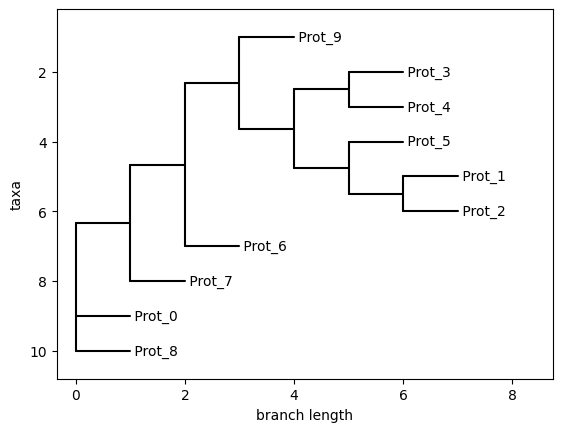

In [34]:
#Muscle
tree = Phylo.read("arbol_muscle.phylotree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)


### Clustalw

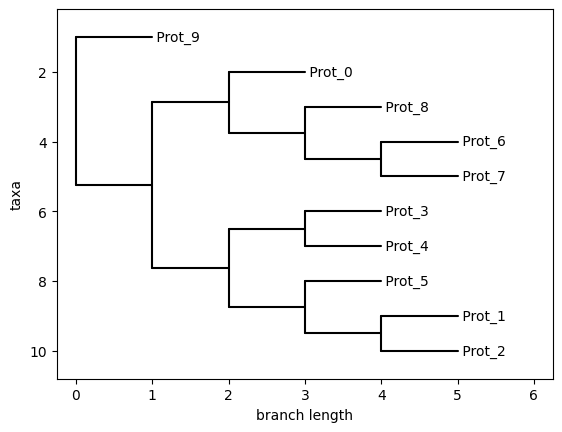

In [35]:
tree = Phylo.read("arbol_clustalw.tree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)


### Mafft

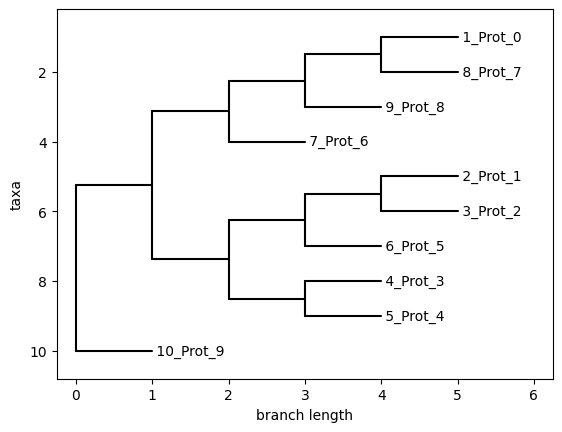

In [36]:
tree = Phylo.read("arbol_mafft.tree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)

# Punto 3. Armamos el alineamiento a partir del arbol guia

Procedimiento:
1. Bajamos en el arbol y contemplamos los casos de alinear...
    * **secuencia con secuencia**

            hacemos el alineamiento de a pares con pairwise2
    * **secuencia con alineamiento de pares**
    
            miramos scores cruzados y nos quedamos con el maximo. Usamos esa "version" de la secuencia como template para agregarlo al AM, poniendo los interlineados necesarios para mantener el score
2. Repetimos a medida que vamos subiendo en el arbol


In [ ]:
from Bio import pairwise2, Phylo
from io import StringIO
from Bio.Align import substitution_matrices

blosum62 = substitution_matrices.load("BLOSUM62")


# Función auxiliar para alinear dos secuencias
def AP(seq1, seq2):
    alignments = pairwise2.align.globalds(seq1, seq2, blosum62, -10, -0.5)
    return alignments[0]

# Función auxiliar para expandir alineamientos
def expandir_secuencia(seq, template):
    """Inserta gaps en seq según la plantilla template (alineada)."""
    expanded = []
    it = iter(seq)
    for ch in template:
        if ch == "-":
            expanded.append("-")
        else:
            expanded.append(next(it))
    return "".join(expanded)

# Fusionar dos alineamientos
def merge_alignments(align1, align2):
    ungapped1 = {sid: s.replace("-", "") for sid, s in align1.items()}
    ungapped2 = {sid: s.replace("-", "") for sid, s in align2.items()}

    mejor_score, mejor_par, mejor_alin = -float("inf"), None, None

    # buscar mejor par cruzado
    for sid1, seq1 in ungapped1.items():
        for sid2, seq2 in ungapped2.items():
            aln = AP(seq1, seq2)
            if aln.score > mejor_score:
                mejor_score, mejor_par, mejor_alin = aln.score, (sid1, sid2), aln

    seq1_aln, seq2_aln = mejor_alin.seqA, mejor_alin.seqB
    sid1, sid2 = mejor_par

    nuevo_alineamiento = {}

    # expandir todo align1 según seq1_aln
    for sid, s in align1.items():
        if sid == sid1:
            nuevo_alineamiento[sid] = seq1_aln
        else:
            nuevo_alineamiento[sid] = expandir_secuencia(s, seq1_aln)

    # expandir todo align2 según seq2_aln
    for sid, s in align2.items():
        if sid == sid2:
            nuevo_alineamiento[sid] = seq2_aln
        else:
            nuevo_alineamiento[sid] = expandir_secuencia(s, seq2_aln)

    return nuevo_alineamiento

# Función principal
def AM(secuencias, newick_tree):
    tree = Phylo.read(StringIO(newick_tree), "newick")

    def recorrer(clade):
        if clade.is_terminal():
            sid = clade.name
            return {sid: secuencias[sid]}
        else:
            children = clade.clades
            alignments = [recorrer(c) for c in children]
            aln = alignments[0]
            for other in alignments[1:]:
                aln = merge_alignments(aln, other)
            return aln

    return recorrer(tree.root)

def AM_lista(lista_secuencias, newick_tree):
    # Crear diccionario interno
    secuencias = {f"S{i+1}": seq for i, seq in enumerate(lista_secuencias)}

    # Llamar a la función original
    return AM(secuencias, newick_tree)


# Árbol Newick

resultado = AM_lista(lista_quinasas, newick_tree)

for sid, aln in resultado.items():
    print(f"{sid}: {aln}")


KeyError: 'A'